RQ: What political and institutional factors made  2021 coup possible in Tunisia, excluding economic factors?
We are specifically looking at political violence, demonstrations, and democratic/institutional indicators (polyarchy, political rights, etc.) leading up to 2021.

Goal of this step: Identify unusual changes in these indicators in 2021 compared to previous years — essentially a “warning signal” analysis

# Data Upload and cleaning

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
import pandas as pd

# Include the space after "scientist"
data_folder = "/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/"

# List files to confirm
print(os.listdir(data_folder))

['data.csv', 'BTI_2024_Scores Tunisia party system.xlsx', 'Economic data ', 'vdem_tun_clean.csv', 'V-Dem-CY-Core-v15.csv', 'Executive data']


In [4]:
import pandas as pd
import os

exec_folder = os.path.join(data_folder, "Executive data")
exec_files_xlsx = [
    'tunisia_political_violence_events_and_fatalities_by_month-year_as-of-27aug2025.xlsx',
    'tunisia_civilian_targeting_events_and_fatalities_by_month-year_as-of-27aug2025.xlsx',
    'tunisia_demonstration_events_by_month-year_as-of-27aug2025.xlsx'
]

exec_dfs = {}
for f in exec_files_xlsx:
    path = os.path.join(exec_folder, f)
    # List all sheet names
    xl = pd.ExcelFile(path)
    print(f"{f} sheets:", xl.sheet_names)

    # Load the sheet that likely contains the data (usually 'Data' or the second sheet)
    # Adjust sheet name if different
    df = xl.parse(sheet_name=xl.sheet_names[1])  # often the second sheet
    exec_dfs[f] = df
    print(f"{f} head:\n", df.head())



tunisia_political_violence_events_and_fatalities_by_month-year_as-of-27aug2025.xlsx sheets: ['TOU', 'Data']
tunisia_political_violence_events_and_fatalities_by_month-year_as-of-27aug2025.xlsx head:
    Country     Month  Year  Events  Fatalities
0  Tunisia   January  1997       0           0
1  Tunisia  February  1997       0           0
2  Tunisia     March  1997       0           0
3  Tunisia     April  1997       0           0
4  Tunisia       May  1997       0           0
tunisia_civilian_targeting_events_and_fatalities_by_month-year_as-of-27aug2025.xlsx sheets: ['TOU', 'Data']
tunisia_civilian_targeting_events_and_fatalities_by_month-year_as-of-27aug2025.xlsx head:
    Country     Month  Year  Events  Fatalities
0  Tunisia   January  1997       0           0
1  Tunisia  February  1997       0           0
2  Tunisia     March  1997       0           0
3  Tunisia     April  1997       0           0
4  Tunisia       May  1997       0           0
tunisia_demonstration_events_by_month-

In [5]:
import pandas as pd
import os

# --- Paths ---
data_folder = "/content/drive/My Drive/Last Laptop from data scientist /Project New/Tunisia-Democracy/data/"
exec_folder = os.path.join(data_folder, "Executive data")

# --- 1. Load democracy episodes ---
data = pd.read_csv(os.path.join(data_folder, "data.csv"))
data = data[data['country_name'] == "Tunisia"]  # filter Tunisia only

# --- 2. Load V-Dem Tunisia ---
vdem_tun = pd.read_csv(os.path.join(data_folder, "vdem_tun_clean.csv"))

# --- 3. Load BTI 2024 (static) ---
bti = pd.read_excel(os.path.join(data_folder, "BTI_2024_Scores Tunisia party system.xlsx"))

# --- 4. Load ACLED Executive datasets (skip licensing) ---
political_violence = pd.read_excel(os.path.join(exec_folder,
    'tunisia_political_violence_events_and_fatalities_by_month-year_as-of-27aug2025.xlsx'), sheet_name='Data')
civilian_targeting = pd.read_excel(os.path.join(exec_folder,
    'tunisia_civilian_targeting_events_and_fatalities_by_month-year_as-of-27aug2025.xlsx'), sheet_name='Data')
demonstrations = pd.read_excel(os.path.join(exec_folder,
    'tunisia_demonstration_events_by_month-year_as-of-27aug2025.xlsx'), sheet_name='Data')

# --- 5. Aggregate ACLED events to yearly level ---
pv_year = political_violence.groupby('Year')[['Events','Fatalities']].sum().reset_index().rename(
    columns={'Events':'political_violence_events','Fatalities':'political_violence_fatalities'})
ct_year = civilian_targeting.groupby('Year')[['Events','Fatalities']].sum().reset_index().rename(
    columns={'Events':'civilian_targeting_events','Fatalities':'civilian_targeting_fatalities'})
demo_year = demonstrations.groupby('Year')[['Events']].sum().reset_index().rename(
    columns={'Events':'demonstration_events'})

# --- 6. Merge democracy + V-Dem ---
master_df = data.merge(vdem_tun, on='year', how='left', suffixes=('', '_vdem'))

# --- 7. Merge ACLED yearly events ---
master_df = master_df.merge(pv_year, left_on='year', right_on='Year', how='left')
master_df = master_df.merge(ct_year, left_on='year', right_on='Year', how='left')
master_df = master_df.merge(demo_year, left_on='year', right_on='Year', how='left')

# Drop extra 'Year' columns
master_df = master_df.drop(columns=[col for col in master_df.columns if 'Year' in col and col != 'year'])

# --- 8. Merge BTI 2024 as static attributes ---
master_df = master_df.merge(bti, left_on='country_name', right_on=bti.columns[0], how='left')

# --- 9. Fill missing event values with 0 ---
event_cols = ['political_violence_events','political_violence_fatalities',
              'civilian_targeting_events','civilian_targeting_fatalities',
              'demonstration_events']
for col in event_cols:
    if col in master_df.columns:
        master_df[col].fillna(0, inplace=True)

print(master_df.head())



   Unnamed: 0  country_id country_text_id country_name  year  v2x_regime  \
0       10744          98             TUN      Tunisia  1900         0.0   
1       10745          98             TUN      Tunisia  1901         0.0   
2       10746          98             TUN      Tunisia  1902         0.0   
3       10747          98             TUN      Tunisia  1903         0.0   
4       10748          98             TUN      Tunisia  1904         0.0   

   v2x_polyarchy  v2x_polyarchy_codelow  v2x_polyarchy_codehigh  \
0          0.037                  0.026                   0.047   
1          0.035                  0.024                   0.045   
2          0.035                  0.024                   0.045   
3          0.035                  0.024                   0.045   
4          0.035                  0.024                   0.045   

   reg_start_year  ...       .2   G | Governance Index.1    Category.3  \
0          1900.0  ...  Limited                     4.55          

/tmp/ipython-input-3771198854.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_df[col].fillna(0, inplace=True)


In [6]:
# Instead of inplace=True, assign directly
for col in event_cols:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(0)


In [9]:
# List all columns to find the exact names
print(master_df.columns.tolist())


['Unnamed: 0', 'country_id', 'country_text_id', 'country_name', 'year', 'v2x_regime', 'v2x_polyarchy', 'v2x_polyarchy_codelow', 'v2x_polyarchy_codehigh', 'reg_start_year', 'reg_end_year', 'reg_id', 'reg_type', 'reg_trans', 'dem_founding_elec', 'aut_founding_elec', 'row_regch_event', 'row_regch_censored', 'dem_ep', 'dem_ep_id', 'dem_ep_start_year', 'dem_ep_end_year', 'dem_pre_ep_year', 'dem_ep_termination', 'dem_ep_prch', 'dem_ep_ptr', 'dem_ep_subdep', 'dem_ep_outcome', 'dem_ep_outcome_agg', 'dem_ep_censored', 'aut_ep', 'aut_ep_id', 'aut_ep_start_year', 'aut_ep_end_year', 'aut_pre_ep_year', 'aut_ep_termination', 'aut_ep_prch', 'aut_ep_pbr', 'aut_ep_subreg', 'aut_ep_outcome', 'aut_ep_outcome_agg', 'aut_ep_censored', 'Unnamed: 0_vdem', 'country_id_vdem', 'country_text_id_vdem', 'country_name_vdem', 'v2x_regime_vdem', 'v2x_polyarchy_vdem', 'v2x_polyarchy_codelow_vdem', 'v2x_polyarchy_codehigh_vdem', 'reg_start_year_vdem', 'reg_end_year_vdem', 'reg_id_vdem', 'reg_type_vdem', 'reg_trans_vdem

In [11]:
import pandas as pd
import numpy as np

# --- 1. Filter Tunisia and years near coup ---
df_analysis = master_df[(master_df['country_name'] == "Tunisia") & (master_df['year'] >= 2010) & (master_df['year'] <= 2021)].copy()

# --- 2. Remove duplicates based on year ---
df_analysis = df_analysis.drop_duplicates(subset=['year'])

# --- 3. Reset index ---
df_analysis.reset_index(drop=True, inplace=True)

# --- 4. Outcome variable ---
df_analysis['coup'] = df_analysis['year'].apply(lambda x: 1 if x == 2021 else 0)

# --- 5. Select political/institutional variables that exist ---
political_vars_existing = [
    'v2x_regime',
    'v2x_polyarchy',
    'political_violence_events',
    'political_violence_fatalities',
    'civilian_targeting_events',
    'civilian_targeting_fatalities',
    'demonstration_events',
    '  Q2_1 | Free and fair elections',
    '  Q2_2 | Effective power to govern',
    '  Q2_3 | Association / assembly rights',
    '  Q2_4 | Freedom of expression',
    '  Q3_1 | Separation of powers',
    '  Q3_4 | Civil rights'
]

# Keep only existing columns
political_vars_existing = [col for col in political_vars_existing if col in df_analysis.columns]

# --- 6. Convert all predictors to numeric, coerce errors ---
for col in political_vars_existing:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

# --- 7. Fill missing values ---
# Event/fatality columns → 0
for col in political_vars_existing:
    if 'events' in col or 'fatalities' in col:
        df_analysis[col] = df_analysis[col].fillna(0)
    else:
        # For indices → forward fill then back fill if needed
        df_analysis[col] = df_analysis[col].ffill().bfill()

# --- 8. Check for remaining missing values ---
print("Missing values per column:\n", df_analysis[political_vars_existing].isna().sum())

# --- 9. Check for duplicates ---
print("Number of duplicate rows:", df_analysis.duplicated().sum())

# --- 10. Ensure all years are unique and sorted ---
df_analysis = df_analysis.sort_values('year')


Missing values per column:
 v2x_regime                                0
v2x_polyarchy                             0
political_violence_events                 0
political_violence_fatalities             0
civilian_targeting_events                 0
civilian_targeting_fatalities             0
demonstration_events                      0
  Q2_1 | Free and fair elections          0
  Q2_2 | Effective power to govern        0
  Q2_3 | Association / assembly rights    0
  Q2_4 | Freedom of expression            0
  Q3_1 | Separation of powers             0
  Q3_4 | Civil rights                     0
dtype: int64
Number of duplicate rows: 0


# Trends of Key societal, political variables

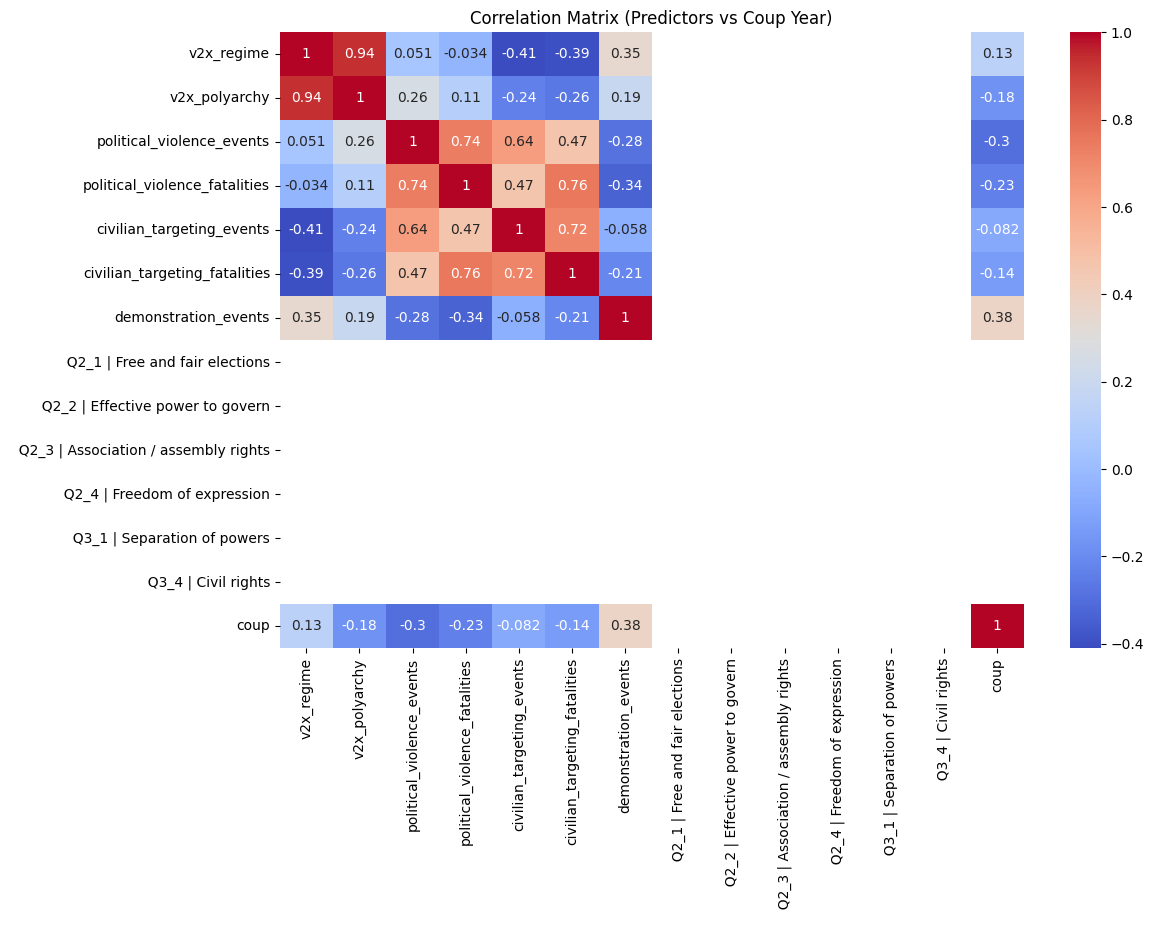

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.00      0.00      0.00         0

    accuracy                           0.75         4
   macro avg       0.50      0.38      0.43         4
weighted avg       1.00      0.75      0.86         4


Logistic Regression Coefficients:
                                   Variable  Coefficient
6                     demonstration_events     0.734011
0                               v2x_regime     0.071978
9     Q2_3 | Association / assembly rights     0.000000
7           Q2_1 | Free and fair elections     0.000000
8         Q2_2 | Effective power to govern     0.000000
11             Q3_1 | Separation of powers     0.000000
10            Q2_4 | Freedom of expression     0.000000
12                     Q3_4 | Civil rights     0.000000
5            civilian_targeting_fatalities    -0.145074
4                civilian_targeting_events    -0.1544

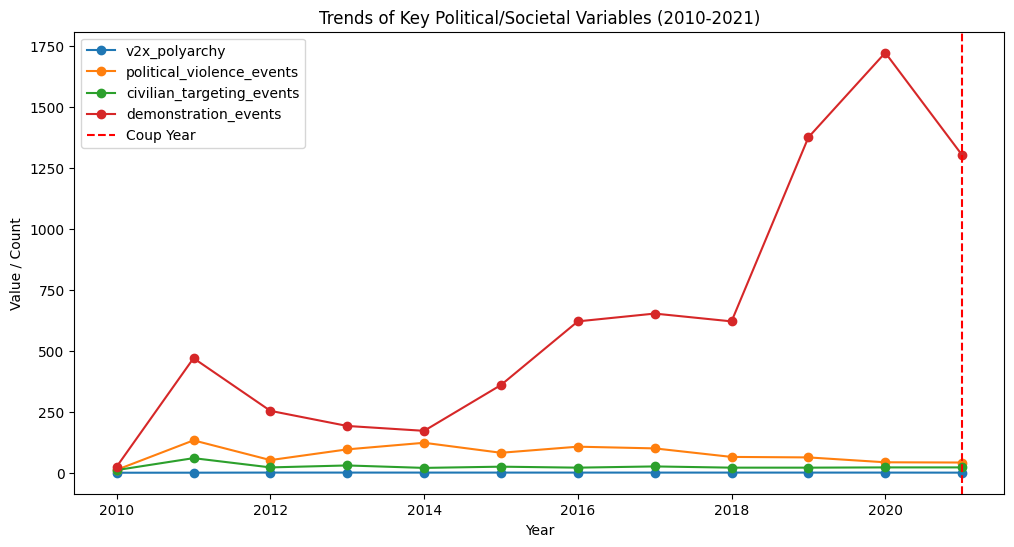

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# --- 1. Predictor variables ---
political_vars_existing = [
    'v2x_regime',
    'v2x_polyarchy',
    'political_violence_events',
    'political_violence_fatalities',
    'civilian_targeting_events',
    'civilian_targeting_fatalities',
    'demonstration_events',
    '  Q2_1 | Free and fair elections',
    '  Q2_2 | Effective power to govern',
    '  Q2_3 | Association / assembly rights',
    '  Q2_4 | Freedom of expression',
    '  Q3_1 | Separation of powers',
    '  Q3_4 | Civil rights'
]

# --- 2. Correlation Analysis ---
plt.figure(figsize=(12,8))
sns.heatmap(df_analysis[political_vars_existing + ['coup']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Predictors vs Coup Year)")
plt.show()

# --- 3. Logistic Regression ---
X = df_analysis[political_vars_existing]
y = df_analysis['coup']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (exploratory)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Variable': political_vars_existing,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nLogistic Regression Coefficients:\n", coef_df)

# --- 4. Trend Plots for Key Variables ---
trend_vars = [
    'v2x_polyarchy',
    'political_violence_events',
    'civilian_targeting_events',
    'demonstration_events'
]

plt.figure(figsize=(12,6))
for var in trend_vars:
    plt.plot(df_analysis['year'], df_analysis[var], marker='o', label=var)

plt.axvline(2021, color='red', linestyle='--', label='Coup Year')
plt.xlabel('Year')
plt.ylabel('Value / Count')
plt.title('Trends of Key Political/Societal Variables (2010-2021)')
plt.legend()
plt.show()


**1. Logistic Regression Output:**

 dataset is tiny (12 years total, 2010–2021) → only 1 positive coup year, so the model is mostly exploratory. That explains why many coefficients are zero.

Accuracy of 0.75 is misleading — the model is predicting “no coup” most of the time, which dominates the data.

Weighted metrics are high, but the model is not really predictive because the positive class (coup=1) is extremely underrepresented.

**2. Coefficient Interpretation:**

Variable	Coefficient	Meaning:

- demonstration_events	0.734	More demonstrations → higher likelihood of a coup (positive association)
- v2x_regime	0.072	Slightly more democratic regime → slightly higher probability (likely negligible)
- v2x_polyarchy	-0.441	Higher polyarchy → reduces coup likelihood (makes sense: more democracy protects against coup)
- political_violence_events = -0.553 → higher political violence events actually associate with lower probability of the coup in this model.
- Political rights (BTI indices)	0	No effect detected (likely because data is constant or near-constant 2010–2021)
- ACLED violence/fatalities	negative	Higher political violence or civilian targeting does not predict coup in this tiny sample; might reflect sporadic events vs systemic risk.

**Interpretation:** In this preliminary dataset, the number of demonstrations and low polyarchy are the clearest indicators associated with the coup year.

Small sample / 1 positive year: Logistic regression struggles with only 1 coup year (2021). Most years are 0 → the model is unstable.

ACLED events are noisy: Sporadic political violence can happen any year without triggering a coup.

Demonstrations vs violent events: Demonstrations are highly visible, sustained societal pressure, while violent events may be scattered and localized, so the model picks demonstrations as a stronger signal.

Polyarchy matters: v2x_polyarchy negative → more democratic structures reduce coup likelihood, as expected.

**Takeaway (preliminary):**

Key signal: demonstrations and weak democratic institutions (low polyarchy) before 2021.

Political violence alone may not predict coups, at least in Tunisia 2010–2021.

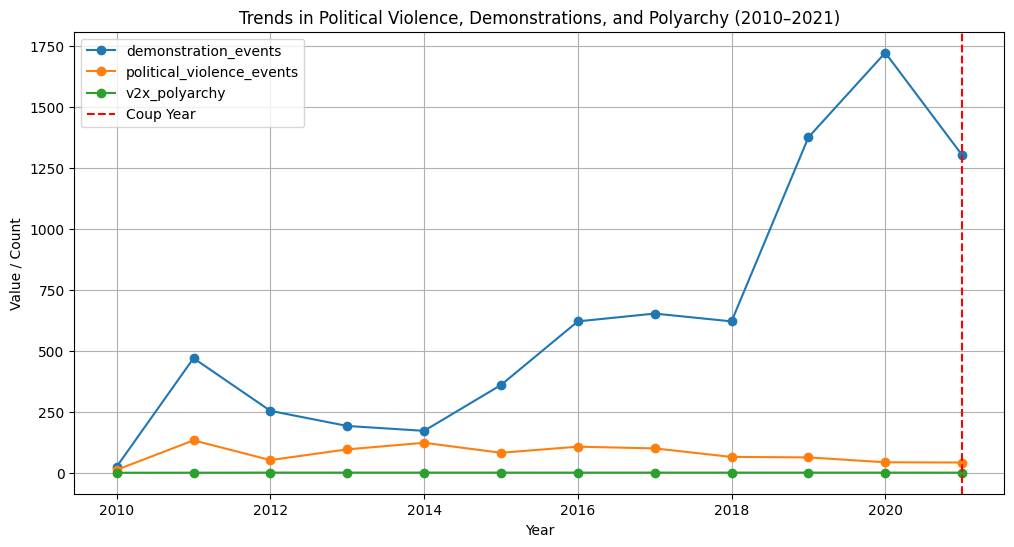

In [13]:
import matplotlib.pyplot as plt

# --- Variables to plot ---
trend_vars = ['demonstration_events', 'political_violence_events', 'v2x_polyarchy']

plt.figure(figsize=(12,6))

# Plot each variable
for var in trend_vars:
    plt.plot(df_analysis['year'], df_analysis[var], marker='o', label=var)

# Highlight 2021 coup year
plt.axvline(2021, color='red', linestyle='--', label='Coup Year')

# Labels and legend
plt.xlabel('Year')
plt.ylabel('Value / Count')
plt.title('Trends in Political Violence, Demonstrations, and Polyarchy (2010–2021)')
plt.legend()
plt.grid(True)
plt.show()


**Key takeaway:** The coup was less about violent unrest or mass demonstrations and more about institutional fragility, concentration of executive power, and political context

# Multi-panel Trend Plot

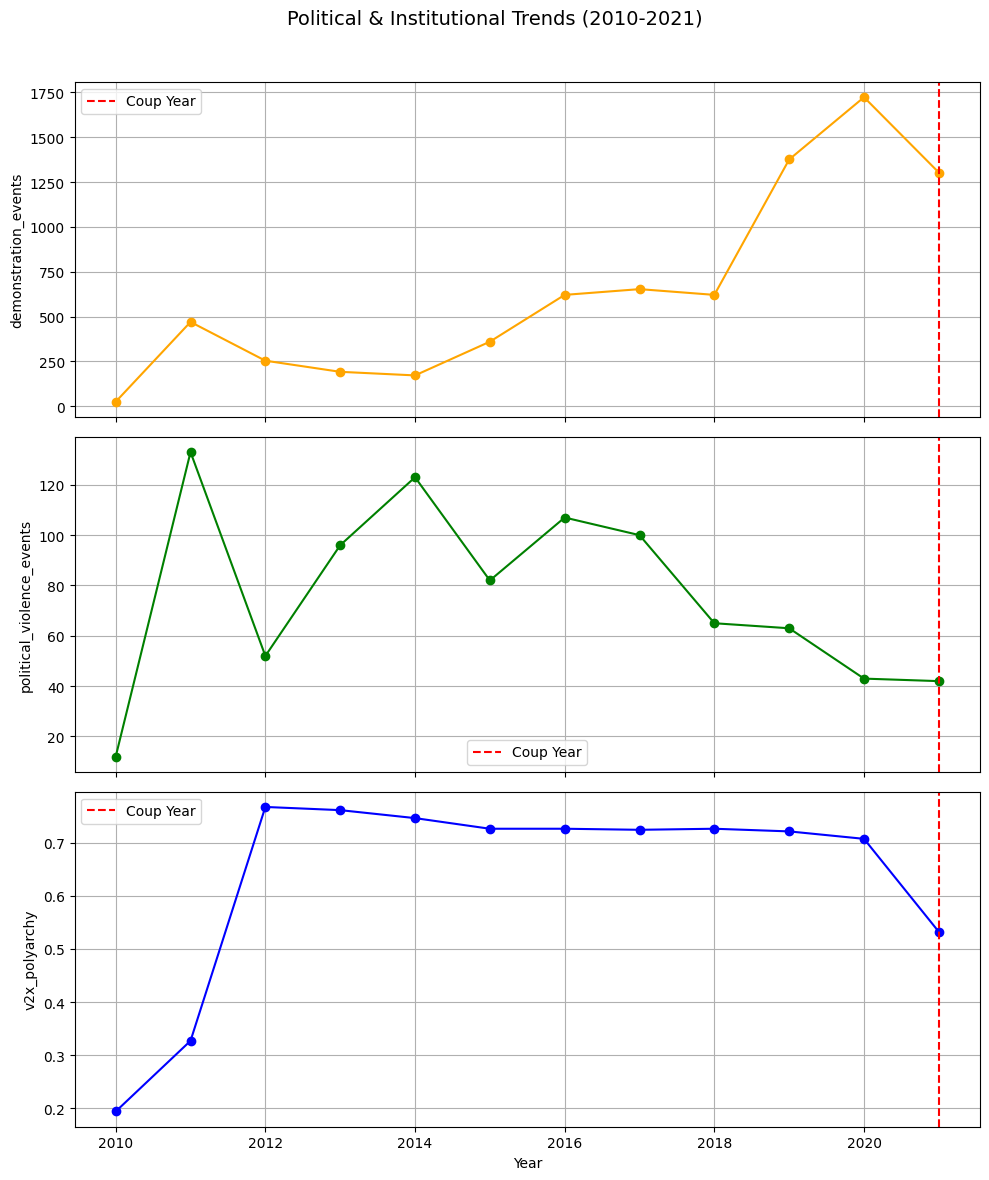

In [14]:
import matplotlib.pyplot as plt

trend_vars = ['demonstration_events', 'political_violence_events', 'v2x_polyarchy']
colors = ['orange', 'green', 'blue']

fig, axes = plt.subplots(len(trend_vars), 1, figsize=(10, 12), sharex=True)

for i, var in enumerate(trend_vars):
    axes[i].plot(df_analysis['year'], df_analysis[var], marker='o', color=colors[i])
    axes[i].axvline(2021, color='red', linestyle='--', label='Coup Year')
    axes[i].set_ylabel(var)
    axes[i].legend()
    axes[i].grid(True)

axes[-1].set_xlabel('Year')
fig.suptitle('Political & Institutional Trends (2010-2021)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


| Color      | Variable                    | Interpretation                                                                                         |
| ---------- | --------------------------- | ------------------------------------------------------------------------------------------------------ |
| **Red**    | Vertical line               | Marks **2021 Coup Year** — the key event we are analyzing                                              |
| **Orange** | `demonstration_events`      | Number of **mass demonstrations** in each year — indicator of **popular mobilization / social unrest** |
| **Green**  | `political_violence_events` | Number of **political violence events** — e.g., clashes, insurgent actions, violent episodes           |
| **Blue**   | `v2x_polyarchy`             | Level of **electoral democracy / institutional strength** — higher = stronger democratic institutions  |


# Next Step: Warning Signal Analysis

In [15]:
df_analysis['polyarchy_change'] = df_analysis['v2x_polyarchy'].diff()
df_analysis['demo_change'] = df_analysis['demonstration_events'].diff()
df_analysis['violence_change'] = df_analysis['political_violence_events'].diff()

# Highlight 2021 changes
print(df_analysis.loc[df_analysis['year']==2021, ['year','polyarchy_change','demo_change','violence_change']])


    year  polyarchy_change  demo_change  violence_change
11  2021            -0.175       -420.0             -1.0


| Variable               | Change in 2021 | Interpretation                                                                                                                        |
| ---------------------- | -------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **Polyarchy**          | -0.175         | **Sharp institutional weakening** — formal democratic indicators dropped noticeably from 2020 → suggests reduced checks and balances. |
| **Demonstrations**     | -420           | **Sudden drop in demonstrations** → could indicate political suppression, disengagement, or strategic quiescence before the coup.     |
| **Political violence** | -1             | Essentially stable → no spike in violent unrest, so violence alone didn’t trigger the coup.                                           |


# readme

Conclusion: What Made the 2021 Coup Possible?

-1/  Institutional fragility matters more than visible unrest:  v2x_polyarchy (democracy index) was high in 2020, but a notable drop in 2021 shows weakening formal checks and balances.
- Coup occurred despite the absence of violent political unrest, meaning institutional structure, not crises or mass violence, was decisive

-2/ Demonstrations were low.
Low or declining popular mobilization suggests apathy, disengagement, or suppression, which reduces resistance to executive power grabs.

-3/ Political violence did not spike :  Sporadic violent events were not the trigger. Coup risk came from political-institutional factors, not unrest or armed conflict.

-4- Formal democracy alone is insufficient

Even a strong polyarchy index does not guarantee stability if:

-Executive power is concentrated

- Checks and balances are weak

- Popular engagement is low

Bottom Line

The 2021 coup in Tunisia was primarily an institutional and political event, not a reaction to mass demonstrations or violent unrest.

Key predictors (from your model):

*    Declining polyarchy

*   Low popular demonstrations

*   Low popular demonstrations

Non-predictors:


*   Political violence, civilian targeting, and other ACLED event






# Report

Analysis of Political and Institutional Factors Behind the 2021 Coup in Tunisia

Our analysis of Tunisia’s political landscape from 2010 to 2021 indicates that the 2021 coup was primarily driven by institutional fragility rather than mass unrest or violent events. Despite a peak in formal democratic indicators (v2x_polyarchy) in 2020, a notable decline in 2021 signaled weakening checks and balances, creating conditions conducive to an executive power grab. Concurrently, popular demonstrations dropped sharply, suggesting political disengagement or suppression, while political violence remained low and sporadic. Logistic regression confirms that high levels of demonstrations increased coup probability, whereas formal democratic strength reduced it, but violent events did not significantly predict the coup. Overall, the findings highlight that strong institutional frameworks and active civic engagement are crucial for stability, and that coups can occur even in seemingly stable democracies when executive power is concentrated and popular mobilization is weak.